In [17]:
import numpy as np
from matplotlib import pyplot as plt

In [113]:
mps = np.load("MPS.npz")
tree = np.load("Tree1.npz")
treex = np.load("Tree4.npz")
ext = np.load("extrpolated_alldof2.npy")

In [11]:
ext.shape

(26, 3, 202)

In [12]:
mps["M"]

array([  2,   4,  16,  32,  48,  64,  96, 128, 192, 256, 384, 512])

In [13]:
tree["M"]

array([  2,   4,  16,  32,  40,  48,  64,  96, 128, 192, 256])

In [14]:
mps["n"].shape

(12, 26, 202)

In [16]:
ref = ext.mean(axis=1)
ref.shape

(26, 202)

In [171]:
ref = (mps["n"][-1] + tree["n"][-1] + treex["n"][-1]) / 3

In [33]:
extrapolated_list_list = []
for dof_idx in range(26):
    extrapolated_list = []
    for npz, M_list in [(mps, np.array([32 ,48])), (tree, np.array([16, 32]))]:
        n_list = []
        for M in M_list:
            n_list.append(npz["n"][npz["M"].tolist().index(M)])
        n_list = np.array(n_list).real
        extrapolated = []
        for i in range(n_list.shape[-1]):
            n_le_vs_M = []
            for n_le in n_list:
                n_le_vs_M.append(n_le[dof_idx][i])
            slope, interception = np.polyfit(1/M_list, n_le_vs_M, deg=1)
            extrapolated.append(interception)
        extrapolated_list.append(extrapolated)
    extrapolated_list_list.append(extrapolated_list)
extrapolated_list_list = np.array(extrapolated_list_list)

In [34]:
extrapolated_list_list.shape

(26, 2, 202)

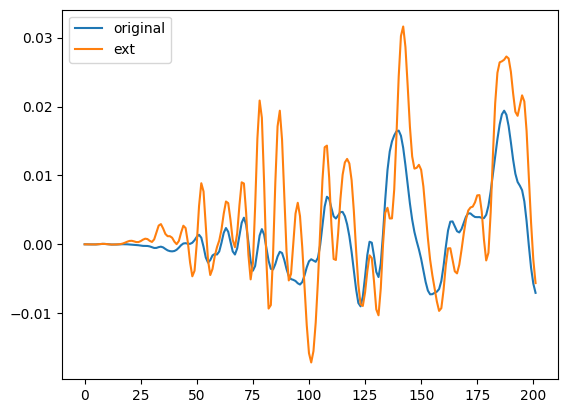

In [41]:
plt.plot(mps["n"][mps["M"].tolist().index(48)][0] - ref[0], label="original")
plt.plot(extrapolated_list_list[0][0] - ref[0], label="ext")
plt.legend()

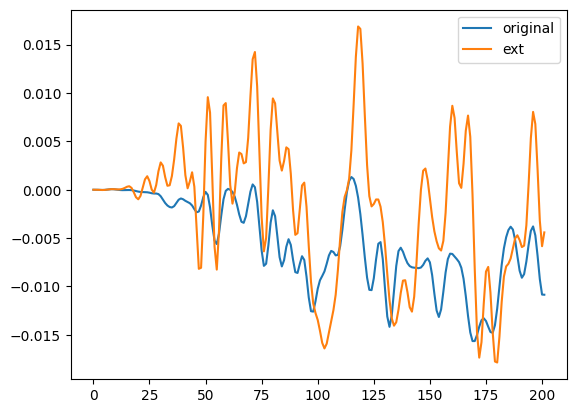

In [43]:
plt.plot(tree["n"][tree["M"].tolist().index(32)][0] - ref[0], label="original")
plt.plot(extrapolated_list_list[0][1] - ref[0], label="ext")
plt.legend()

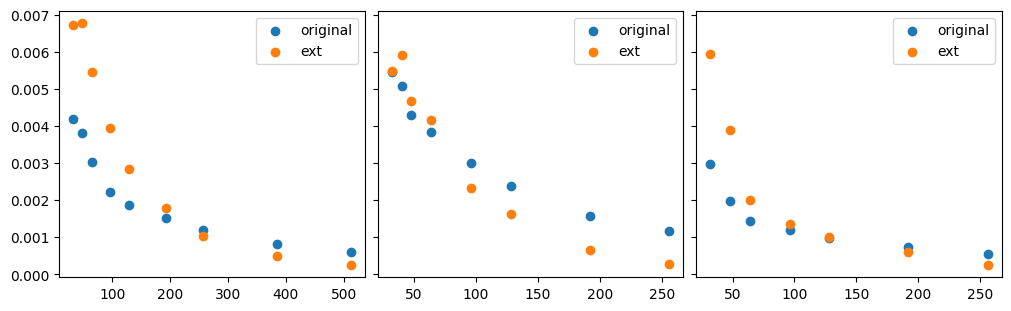

In [169]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained", sharey=True)

for fig_i, npz in enumerate([mps, tree, treex]):
    n_array = npz["n"]
    extrapolated_list_list = []
    m_list = []
    for m_idx in range(len(npz["M"])-1):
        M_fit = np.array([npz["M"][m_idx], npz["M"][m_idx+1]])
        if M_fit[1] < 32:
            continue
        m_list.append(M_fit[1])
        extrapolated_list = []
        for dof_idx in range(26):
            extrapolated = []
            for t_idx in range(202):
                n_le_vs_M = np.array([n_array[m_idx][dof_idx][t_idx], n_array[m_idx+1][dof_idx][t_idx]])
                slope, interception = np.polyfit(1/M_fit, n_le_vs_M, deg=1)
                extrapolated.append(interception)
            extrapolated_list.append(extrapolated)
        extrapolated_list_list.append(extrapolated_list)
    extrapolated_list_list = np.array(extrapolated_list_list)

    dof_idx = 0
    error_original_list = []
    error_ext_list = []
    for i, m in enumerate(m_list):
        m_idx = npz["M"].tolist().index(m)
        error_original = np.abs(n_array[m_idx][dof_idx] - ref[dof_idx]).mean()
        error_ext = np.abs(extrapolated_list_list[i][dof_idx] - ref[dof_idx]).mean()
        error_original_list.append(error_original)
        error_ext_list.append(error_ext)

    plt.sca(axs[fig_i])
    plt.scatter(m_list, error_original_list, label="original")
    plt.scatter(m_list, error_ext_list, label="ext")
    plt.legend()
plt.show()

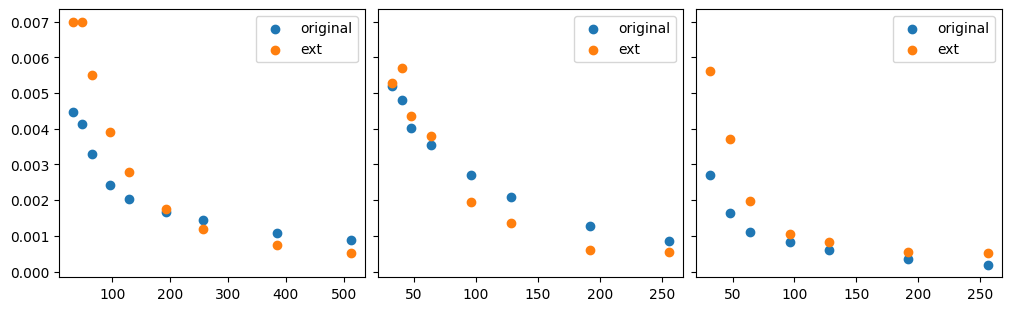

In [172]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained", sharey=True)

for fig_i, npz in enumerate([mps, tree, treex]):
    n_array = npz["n"]
    extrapolated_list_list = []
    m_list = []
    for m_idx in range(len(npz["M"])-1):
        M_fit = np.array([npz["M"][m_idx], npz["M"][m_idx+1]])
        if M_fit[1] < 32:
            continue
        m_list.append(M_fit[1])
        extrapolated_list = []
        for dof_idx in range(26):
            extrapolated = []
            for t_idx in range(202):
                n_le_vs_M = np.array([n_array[m_idx][dof_idx][t_idx], n_array[m_idx+1][dof_idx][t_idx]])
                slope, interception = np.polyfit(1/M_fit, n_le_vs_M, deg=1)
                extrapolated.append(interception)
            extrapolated_list.append(extrapolated)
        extrapolated_list_list.append(extrapolated_list)
    extrapolated_list_list = np.array(extrapolated_list_list)

    dof_idx = 0
    error_original_list = []
    error_ext_list = []
    for i, m in enumerate(m_list):
        m_idx = npz["M"].tolist().index(m)
        error_original = np.abs(n_array[m_idx][dof_idx] - ref[dof_idx]).mean()
        error_ext = np.abs(extrapolated_list_list[i][dof_idx] - ref[dof_idx]).mean()
        error_original_list.append(error_original)
        error_ext_list.append(error_ext)

    plt.sca(axs[fig_i])
    plt.scatter(m_list, error_original_list, label="original")
    plt.scatter(m_list, error_ext_list, label="ext")
    plt.legend()
plt.show()